# Medical insurance analysis

## Objectives 
In this project, we will:
 - Load the data as a `pandas` dataframe
 - Clean the data
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 

# import and clean data

### import modules

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline 
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harishkumardatalab/medical-insurance-price-prediction/Medical_insurance.csv")

the first 5 row of the data

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Let's see if the 'nan' is present  of our dataframe

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


This dataframe don't have a nan. 

The charges column has values which are more than 2 decimal places long. let's change it for 2 decimal places.

In [5]:
df[['charges']]=np.round(df[['charges']],2)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92
1,18,male,33.770,1,no,southeast,1725.55
2,28,male,33.000,3,no,southeast,4449.46
3,33,male,22.705,0,no,northwest,21984.47
4,32,male,28.880,0,no,northwest,3866.86


Here we change the format dtype of categories variables such as sex and smoker and region

In [6]:
df['smoker'] = pd.get_dummies(df['smoker'], drop_first=True, dtype=int)
df['sex'] = pd.get_dummies(df['sex'], drop_first=True, dtype=int)
df['region'] = pd.factorize(df['region'])[0]+1
#df['region'] = pd.get_dummies(df['region'], drop_first=True, dtype=int)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92
1,18,1,33.770,1,0,2,1725.55
2,28,1,33.000,3,0,2,4449.46
3,33,1,22.705,0,0,3,21984.47
4,32,1,28.880,0,0,3,3866.86
5,31,0,25.740,0,0,2,3756.62
6,46,0,33.440,1,0,2,8240.59
7,37,0,27.740,3,0,3,7281.51
8,37,1,29.830,2,0,4,6406.41
9,60,0,25.840,0,0,3,28923.14


Now the data is ready for analysis. 

# Exploratory data analysis 

Let's view the regression plot of charges 

(0.0, 66902.85800000001)

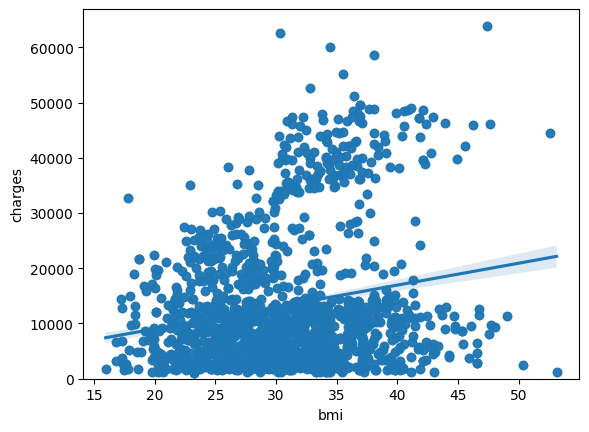

In [7]:
sns.regplot(x='bmi', y='charges', data=df)
plt.ylim(0,)

The box of charges

<Axes: xlabel='smoker', ylabel='charges'>

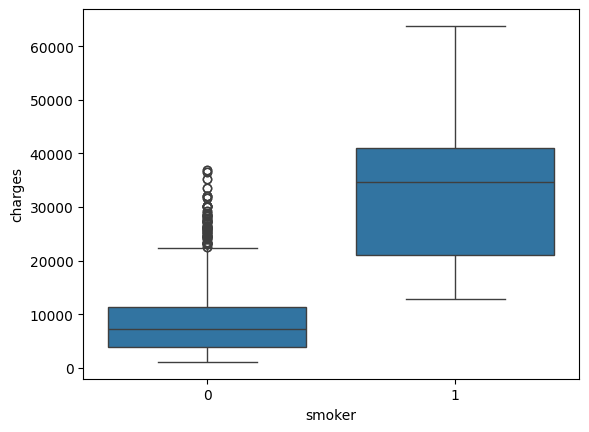

In [8]:
sns.boxplot(x= 'smoker', y='charges', data=df)

Let's see the corelation for the dataset

In [9]:
cor= df.corr()
cor

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.000932,0.298624
sex,-0.026046,1.000000,0.042924,0.016020,0.082326,-0.004808,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,-0.159178,0.199846
children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.016111,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.006751,0.788783
region,-0.000932,-0.004808,-0.159178,-0.016111,0.006751,1.000000,0.013530
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.013530,1.000000


# Model development

Let's fit a linear regression model that may be used to predict the `charges` value by using the smoker attribute of the dataset. 

In [10]:
X = df[['smoker']]
Y = df[['charges']]
lm  = LinearRegression()
lm.fit(X,Y)
print("R^2 score is", lm.score(X,Y))

R^2 score is 0.6221791733924185


by using the smoker attribute of the dataset. 

In [11]:
Z = df[["age", "sex", "bmi", "children", "smoker", "region"]]
lm.fit(Z,Y)
print("R^2 score is ", lm.score(Z, Y))

R^2 score is  0.7507632145850487


For polynomial regression 

In [12]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print("R^2 is ", r2_score(Y,ypipe))

R^2 is  0.8463461616331209


# Model refinement
We are going to split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [13]:
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)

Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. 

In [14]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print("R^2 is ", r2_score(y_test,yhat))

R^2 is  0.6776458806195913


Appication of  polynomial transformation to the training parameters with degree=2.

In [15]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.fit_transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print("R^2 is ", r2_score(y_test,y_hat))

R^2 is  0.7865282098719917
